In [41]:
import pandas as pd
import numpy as np

In [42]:
analysis_df = pd.read_csv('./ecir_res/union_output_v2.csv')
single_df = pd.read_csv('./ecir_res/single_output_v2.csv')

In [43]:
single_df.query('k==10').query('retriever=="e5"').query('task=="nq"').query('target_metric=="f1"')

,k,retriever,task,target_metric,QPP_Method,Spearman,Kendall
1248,10,e5,nq,f1,nqc,0.1689,0.1285
1249,10,e5,nq,f1,maxScore,0.1611,0.1217
1250,10,e5,nq,f1,spatial,0.0789,0.0595
1251,10,e5,nq,f1,a_ratio,0.1917,0.1460
1252,10,e5,nq,f1,bertQPP,0.1398,0.1065
1253,10,e5,nq,f1,prob(k),0.3999,0.3009
1254,10,e5,nq,f1,max(perpC),0.0527,0.0400
1255,10,e5,nq,f1,min(perpC),0.0388,0.0295
1256,10,e5,nq,f1,avg(perpC),0.0471,0.0357
1257,10,e5,nq,f1,itg(perpC),0.0537,0.0407


In [44]:
df_dict = {}

gpp_df = analysis_df[analysis_df['Prediction Name']=='GPP']
_df = analysis_df[analysis_df['Prediction Name']=='RPP']

df_dict.update({'gpp': gpp_df, 'rpp': rpp_df})

In [45]:
from tools import fisher_test
from IPython.display import display, HTML

# Function to replace True/False with tick/blank
def tickmark(val):
    return "✔️" if val else ""

# Function to bold if Sig:e5%3 is True
def bold_sig(val, sig):
    return f"<b>{val:.4f}</b>" if sig else f"{val:.4f}"

def f(_x):
    # _dict = {'0': 'QPP', '1': 'PerpC', '2': 'QualT5', '3': 'Readability'}
    output_list = [False, False, False, False]
    for i in _x[1:]:
        output_list[int(i)] = True
    return output_list

def significance(_n, _x, _b):
    _oa, _ob = fisher_test.compare_spearman_rhos(_n, _b, _x).values()
    return (_oa<0)&(_ob<0.05)

In [46]:
single_df

,k,retriever,task,target_metric,QPP_Method,Spearman,Kendall
0,2,bm25,nq,f1,nqc,0.0610,0.0467
1,2,bm25,nq,f1,maxScore,0.1609,0.1235
2,2,bm25,nq,f1,spatial,0.2166,0.1659
3,2,bm25,nq,f1,a_ratio,0.1353,0.1040
4,2,bm25,nq,f1,bertQPP,0.2079,0.1594
...,...,...,...,...,...,...,...
1363,10,e5,dl,utility,itg(perpC),0.2096,0.1420
1364,10,e5,dl,utility,max(docQual),-0.0897,-0.0593
1365,10,e5,dl,utility,min(docQual),-0.1382,-0.0975
1366,10,e5,dl,utility,avg(docQual),-0.1444,-0.0902


In [47]:
import copy
import itertools

def visualise_a_group_of_results(prediction_task, postgen_bool):
    y = 0
    
    show_experiments = []
    for k, retr in itertools.product([2], ['bm25', 'mt5', 'e5']):
    
        x = df_dict[prediction_task].query(f'Use_Postgen=={postgen_bool}').copy()
        n = x['Number of Queries'].values[0]
        x = x.reset_index(drop=True)
        x = x[x['QA Task']=='nq']
        x = x[x['Retriever']==retr]
        x = x[x['Top-Retrieved Docs']==k]
        # x = x[x['Combination_Number'].isin(['p0', 'p01', 'p012', 'p0123'])]
        x = x[x['Combination_Number'].isin(['p0', 'p01', 'p013', 'p0123'])]
        identifier = f'{retr}'
        show_experiments.append(identifier)
        
        QPP_only_outcome = x[x.Combination_Number=='p0']['Rho'].values[0]
        postgen_only_outcome = single_df[(single_df.k==k)&(single_df.retriever==retr)&(single_df.task=='nq')&\
                                (single_df.target_metric==('f1' if prediction_task=='gpp' else 'utility'))&(single_df.QPP_Method=='prob(k)')]['Spearman'].values[0]
        print(postgen_only_outcome)
        
        x_a = pd.DataFrame(x.Combination_Number.apply(f).tolist(), columns=['QPP', 'PerpC', 'Qual', 'Read'])
        x_b = pd.DataFrame(x.Use_Postgen.tolist(), columns=['PerpA'])

        x = pd.concat([x_b, x_a, x.reset_index(drop=True)], axis=1).drop(columns=['Prediction Name', 'QA Task', 'Use_Postgen', 'Top-Retrieved Docs', 'Number of Queries', \
                                                                         'Tau', 'Best Single Tau', 'Best Single Rho', 'Best Single Signal', \
                                                                         'Combination_Number', 'Retriever'])
        x = x.rename(columns={'Rho': identifier})
        if(postgen_bool==False):
            x[f'Sig:{identifier}'] = x[identifier].apply(lambda _x: significance(n, _x, QPP_only_outcome))
        else:
            pre_gen_counterpart = df_dict[prediction_task].query(f'Use_Postgen==False').query('Retriever==@retr')
            pre_gen_counterpart = pre_gen_counterpart[pre_gen_counterpart['QA Task']=='nq']
            pre_gen_counterpart = pre_gen_counterpart[pre_gen_counterpart['Top-Retrieved Docs']==k]
            pre_gen_counterpart = pre_gen_counterpart[pre_gen_counterpart['Combination_Number'].isin(['p0', 'p01', 'p013', 'p0123'])]
            # print(pre_gen_counterpart)
            # print(x, x[identifier])
            uni_sig = []
            for rho0, rho1 in zip(x[identifier], pre_gen_counterpart.Rho.values):
                uni_sig.append((significance(n, rho0, rho1))&(significance(n, rho0, postgen_only_outcome)))
            x[f'Sig:{identifier}'] = uni_sig
            # x[f'Sig:{identifier}'] = x[identifier].apply(lambda _x: significance(n, _x, pre_gen_counterpart.Rho.values))
        # x[identifier] = x[identifier].apply(lambda _x: round(_x, 4))
        # print(x[identifier])
    
        if(type(y)==int):
            y = copy.deepcopy(x)
        else:
            y = pd.concat([y, x[[identifier, f'Sig:{identifier}']].copy()], axis=1)
    
    # Apply formatting
    df_display = y.copy()
        
    # Replace first 4 columns with ticks
    for col in ["PerpA", "QPP", "PerpC", "Qual", "Read"]:
        df_display[col] = df_display[col].apply(tickmark)
        
    # Bold e5%3 where Sig:e5%3 is True
    for _id in show_experiments:
        
        df_display[_id] = [
            bold_sig(v, s) for v, s in zip(y[_id], y[f"Sig:{_id}"])
        ]
        
        df_display = df_display.drop(columns=[f"Sig:{_id}"])

    return df_display



# For the Tables

In [48]:
display_dfs = [[], []]
display_dfs[0].append(visualise_a_group_of_results('rpp', False))
display_dfs[0].append(visualise_a_group_of_results('gpp', False))
display_dfs[1].append(visualise_a_group_of_results('rpp', True))
display_dfs[1].append(visualise_a_group_of_results('gpp', True))

0.1468
0.1351
0.147
0.3037
0.2579
0.2873
0.1468
0.1351
0.147
0.3037
0.2579
0.2873


In [49]:
visualise_a_group_of_results('rpp', True)

0.1468
0.1351
0.147


,PerpA,QPP,PerpC,Qual,Read,bm25,mt5,e5
0,✔️,✔️,,,,0.2387,0.2283,<b>0.2513</b>
1,✔️,✔️,✔️,,,0.2534,0.2280,<b>0.2474</b>
2,✔️,✔️,✔️,,✔️,0.2573,0.2404,<b>0.2476</b>
3,✔️,✔️,✔️,✔️,✔️,0.2539,0.2563,<b>0.2472</b>


In [50]:
# display(HTML(display_dfs[0][0].style.hide(axis="index").to_html()))

In [51]:
# display(HTML(display_dfs[0][1].style.hide(axis="index").to_html()))

In [52]:
# display(HTML(display_dfs[1][0].style.hide(axis="index").to_html()))

In [53]:
# display(HTML(display_dfs[1][1].style.hide(axis="index").to_html()))

In [54]:
display_dfs[0][0]

,PerpA,QPP,PerpC,Qual,Read,bm25,mt5,e5
0,,✔️,,,,0.2146,0.2008,0.2155
1,,✔️,✔️,,,0.2365,0.2001,0.2110
2,,✔️,✔️,,✔️,0.2419,0.2136,0.2101
3,,✔️,✔️,✔️,✔️,0.2380,<b>0.2350</b>,0.2093


In [55]:
first_row = pd.concat([display_dfs[0][0], display_dfs[0][1].iloc[:, -3:]], axis=1)
second_row = pd.concat([display_dfs[1][0], display_dfs[1][1].iloc[:, -3:]], axis=1)
union_df = pd.concat([first_row, second_row], axis=0)
union_df.iloc[4:, :] = union_df.iloc[4:, :].apply(lambda _x: round(_x, 4))
print(union_df.to_latex(index=False))

\begin{tabular}{lllllllllll}
\toprule
PerpA & QPP & PerpC & Qual & Read & bm25 & mt5 & e5 & bm25 & mt5 & e5 \\
\midrule
 & ✔️ &  &  &  & 0.2146 & 0.2008 & 0.2155 & 0.2454 & 0.2861 & 0.2952 \\
 & ✔️ & ✔️ &  &  & 0.2365 & 0.2001 & 0.2110 & <b>0.2821</b> & 0.3040 & 0.3094 \\
 & ✔️ & ✔️ &  & ✔️ & 0.2419 & 0.2136 & 0.2101 & <b>0.2948</b> & 0.3071 & 0.3075 \\
 & ✔️ & ✔️ & ✔️ & ✔️ & 0.2380 & <b>0.2350</b> & 0.2093 & <b>0.2945</b> & <b>0.3253</b> & 0.3088 \\
✔️ & ✔️ &  &  &  & 0.2387 & 0.2283 & <b>0.2513</b> & <b>0.3507</b> & <b>0.3616</b> & <b>0.3915</b> \\
✔️ & ✔️ & ✔️ &  &  & 0.2534 & 0.2280 & <b>0.2474</b> & <b>0.3653</b> & <b>0.3726</b> & <b>0.3988</b> \\
✔️ & ✔️ & ✔️ &  & ✔️ & 0.2573 & 0.2404 & <b>0.2476</b> & <b>0.3729</b> & <b>0.3737</b> & <b>0.3977</b> \\
✔️ & ✔️ & ✔️ & ✔️ & ✔️ & 0.2539 & 0.2563 & <b>0.2472</b> & <b>0.3727</b> & <b>0.3856</b> & <b>0.3974</b> \\
\bottomrule
\end{tabular}



In [56]:
union_df.style.hide(axis="index")

PerpA,QPP,PerpC,Qual,Read,bm25,mt5,e5,bm25,mt5,e5
,✔️,,,,0.2146,0.2008,0.2155,0.2454,0.2861,0.2952
,✔️,✔️,,,0.2365,0.2001,0.2110,0.2821,0.3040,0.3094
,✔️,✔️,,✔️,0.2419,0.2136,0.2101,0.2948,0.3071,0.3075
,✔️,✔️,✔️,✔️,0.2380,0.2350,0.2093,0.2945,0.3253,0.3088
✔️,✔️,,,,0.2387,0.2283,0.2513,0.3507,0.3616,0.3915
✔️,✔️,✔️,,,0.2534,0.2280,0.2474,0.3653,0.3726,0.3988
✔️,✔️,✔️,,✔️,0.2573,0.2404,0.2476,0.3729,0.3737,0.3977
✔️,✔️,✔️,✔️,✔️,0.2539,0.2563,0.2472,0.3727,0.3856,0.3974


### For Table 1

In [57]:
import itertools

qpps = ['nqc', 'maxScore', 'spatial', 'a_ratio', 'bertQPP']

table1_df = 0

for prediction_task, retriever in itertools.product(['utility', 'f1'], ['bm25', 'mt5', 'e5']):
    x = single_df.query('task=="nq"').query('k==2').query('QPP_Method in @qpps').query('target_metric==@prediction_task').drop(columns=['Kendall', 'k', 'task'])
    x = x[x['retriever']==retriever].query(f'target_metric==@prediction_task').drop(columns=['retriever', 'target_metric'])
    x = x.rename(columns={'Spearman': retriever})
    x = x.reset_index(drop=True)
    x[retriever] = x[retriever].apply(lambda _x: f"{_x:.4f}")
    if(type(table1_df)==int):
        table1_df = x
    else:
        table1_df = pd.concat([table1_df, x.iloc[:, -1:]], axis=1)

latex_table1_string = table1_df.to_latex(index=False)
print(latex_table1_string)

\begin{tabular}{lllllll}
\toprule
QPP_Method & bm25 & mt5 & e5 & bm25 & mt5 & e5 \\
\midrule
nqc & 0.0694 & -0.0643 & 0.0994 & 0.0610 & -0.1288 & 0.1210 \\
maxScore & 0.1485 & 0.1625 & 0.1288 & 0.1609 & 0.2218 & 0.2344 \\
spatial & 0.1739 & 0.2027 & 0.1025 & 0.2166 & 0.2992 & 0.1922 \\
a_ratio & 0.1565 & 0.0136 & 0.1913 & 0.1353 & -0.0483 & 0.2470 \\
bertQPP & 0.1898 & 0.1474 & 0.1352 & 0.2079 & 0.1641 & 0.1630 \\
\bottomrule
\end{tabular}



In [58]:
single_df.query("task=='nq'").query("QPP_Method=='prob(k)'").query("target_metric=='utility'").query("k==2")

,k,retriever,task,target_metric,QPP_Method,Spearman,Kendall
27,2,bm25,nq,utility,prob(k),0.1468,0.1095
99,2,mt5,nq,utility,prob(k),0.1351,0.0992
171,2,e5,nq,utility,prob(k),0.1470,0.1074


# For the Graph

['A-Pair-Ratio', 'Perp$A$', 'PostGen-Ensmbl', 'PreGen-Ensmbl'] [<matplotlib.lines.Line2D object at 0x7f3af2a3f790>, <matplotlib.lines.Line2D object at 0x7f3aed31b700>, <matplotlib.lines.Line2D object at 0x7f3ae7b038b0>, <matplotlib.lines.Line2D object at 0x7f3ae7b002e0>]


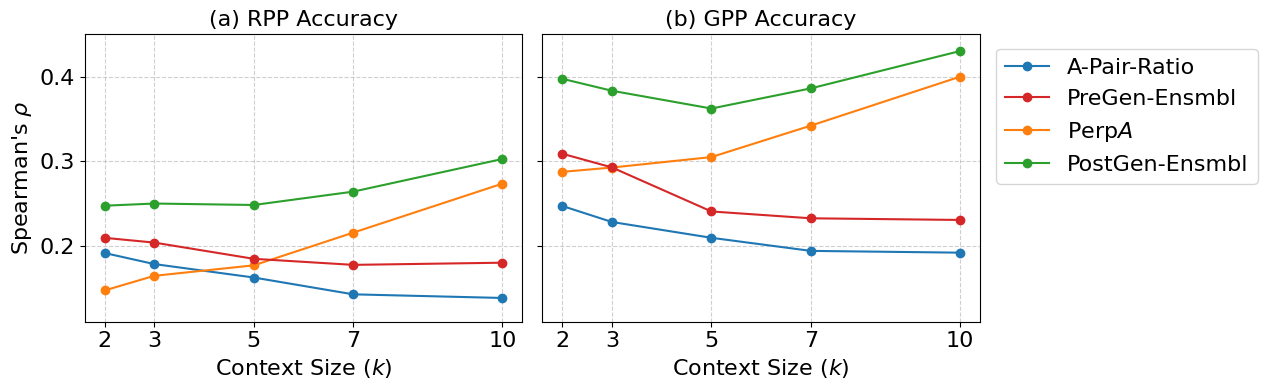

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

x = [2, 3, 5, 7, 10]
PREFIXES = ['a', 'b']
FONT_SIZE = 16
CONVERT_DICT = {'a_ratio': 'A-Pair-Ratio', 'p0123': 'PreGen-Ensmbl', 'p01234': 'PostGen-Ensmbl', 'prob(k)': f'Perp$A$'}

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax, pp_name in zip(axs.flat, ['RPP', 'GPP']):
    prefix = '(a)' if(pp_name=='RPP') else'(b)'
    target_name = ('f1' if pp_name=='GPP' else 'utility')
    
    single_part = single_df[single_df.QPP_Method.isin(['a_ratio', 'prob(k)'])].query('retriever=="e5"').query('task=="nq"').query('target_metric==@target_name')
    single_part = single_part[['k', 'QPP_Method', 'Spearman']]
    single_part = single_part.rename(columns={'QPP_Method': 'method', 'Spearman': 'Rho'})
    
    e5_analysis = analysis_df[analysis_df['QA Task']=='nq'].query('Retriever=="e5"')
    e5_analysis = e5_analysis[e5_analysis['Prediction Name']==pp_name]
    # pre_part = e5_analysis[e5_analysis.Combination_Number.isin(['p0', 'p01', 'p012', 'p0123'])].query("Use_Postgen==False")
    pre_part = e5_analysis[e5_analysis.Combination_Number.isin(['p0123'])].query("Use_Postgen==False")
    post_part = e5_analysis[e5_analysis.Combination_Number=='p0123'].query("Use_Postgen==True")
    post_part.Combination_Number = 'p01234'
    graph_df = pre_part.copy()
    graph_df = pd.concat([pre_part,post_part], axis=0)
    graph_df = graph_df[['Top-Retrieved Docs', 'Combination_Number', 'Rho']]
    graph_df = graph_df.rename(columns={'Top-Retrieved Docs': 'k', 'Combination_Number': 'method'})
    graph_df = pd.concat([graph_df,single_part], axis=0)
    graph_df.method = graph_df.method.apply(lambda x: CONVERT_DICT[x])
    # Pivot for plotting
    pivot_df = graph_df.pivot(index="k", columns="method", values="Rho")
    
    # Plot
    # ax.figure(figsize=(8,6))
    for method in pivot_df.columns:
        if(pp_name=='GPP'):
            ax.plot(pivot_df.index, pivot_df[method], marker="o", label=method)
        else:
            ax.plot(pivot_df.index, pivot_df[method], marker="o", label='_Hidden')
    
    
    ax.set_xlabel("Context Size ($k$)", fontsize=FONT_SIZE)
    ax.set_ylabel(f"Spearman's $\\rho$", fontsize=FONT_SIZE)

    ax.set_xticks(x)  # Set x-axis ticks to 2,3,5,7,10
    ax.set_xticklabels(x, fontsize=FONT_SIZE)
    
    y = np.arange(0.2, 0.47, 0.1)
    y = [round(i,1) for i in y]
    ylim = [0.13-0.02, 0.45]
    ax.set_ylim(ylim)
    ax.set_yticks(y)
    ax.set_yticklabels(y, fontsize=FONT_SIZE)
    
    # ax.set_title(f"{pp_name} Accuracy with Various Context Size", fontsize=FONT_SIZE)
    ax.set_title(f"{prefix} {pp_name} Accuracy", fontsize=FONT_SIZE)
    ax.grid(True, linestyle="--", alpha=0.6)

for ax in axs.flat:
    ax.label_outer()
plt.tight_layout()

handles, labels = plt.gca().get_legend_handles_labels()
order = ["A-Pair-Ratio", "PreGen-Ensmbl", "Perp$A$", "PostGen-Ensmbl"]

# Reorder by matching labels
handles = [handles[labels.index(m)] for m in order if m in labels]
print(labels, handles)
fig.legend(handles, order, ncol=1, fontsize=FONT_SIZE, loc='lower left', bbox_to_anchor=(0.99, 0.5))
# fig.legend(ncol=4, fontsize=FONT_SIZE, loc='lower center', bbox_to_anchor=(0.5, 1))


plt.savefig("./plotting/images/lineplot_v2.pdf", format="pdf", bbox_inches="tight")
plt.savefig("./plotting/images/lineplot_v2.svg", format="svg", bbox_inches="tight")
plt.show()

# Average Prediction Target

In [60]:
from tools import process_results, fisher_test
import numpy as np

retriever = 'mt5'
zero_evals = process_results.load_json(f'../../rag_utility/eval_results/short_answers_0shot_1calls_0_0_bm25_dl_nq_test_concise_eval.json')
k_evals = process_results.load_json(f'../../rag_utility/eval_results/short_answers_2shot_1calls_1_0_{retriever}_dl_nq_test_concise_eval.json')

In [61]:
print(len(zero_evals))
mean_zero = np.mean([i['0']['0']['F1'] for i in zero_evals.values()])

3610


In [62]:
print(len(k_evals))
mean_two = np.mean([i['0']['0']['F1'] for i in k_evals.values()])
print(mean_two)

3610
0.4018758265434165


In [63]:
mean_two - mean_zero

0.18692593361968882